# **Automatidata project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

The data consulting firm Automatidata has recently hired you as the newest member of their data analytics team. Their newest client, the NYC Taxi and Limousine Commission (New York City TLC), wants the Automatidata team to build a multiple linear regression model to predict taxi fares using existing data that was collected over the course of a year. The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and A/B testing.

The Automatidata team has reviewed the results of the A/B testing. Now it’s time to work on predicting the taxi fare amounts. You’ve impressed your Automatidata colleagues with your hard work and attention to detail. The data team believes that you are ready to build the regression model and update the client New York City TLC about your progress.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# Course 4 End-of-course project: Build a multiple linear regression model

In this activity, you will build a multiple linear regression model. As you've learned, multiple linear regression helps you estimate the linear relationship between one continuous dependent variable and two or more independent variables. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed. 

Completing this activity will help you practice planning out and buidling a multiple linear regression model based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.
<br/>

**The purpose** of this project is to demostrate knowledge of EDA and a multiple linear regression model

**The goal** is to build a multiple linear regression model and evaluate the model
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a multiple linear regression model?

**Part 2:** Model Building and evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.

# Build a multiple linear regression model

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: **Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.


### Task 1. Imports and loading
Import the packages that you've learned are needed for building linear regression models.

In [80]:
# Imports
# Packages for numerics + dataframes
### YOUR CODE HERE ###
import pandas as pd
import numpy as np

# Packages for visualization
### YOUR CODE HERE ### 

import seaborn as sns
from matplotlib import pyplot as plt

# Packages for date conversions for calculating trip durations
### YOUR CODE HERE ###

from datetime import datetime
from datetime import date
from datetime import timedelta


# Packages for OLS, MLR, confusion matrix
### YOUR CODE HERE ###
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
 


**Note:** `Pandas` is used to load the NYC TLC dataset. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [81]:
# Load dataset into dataframe 
df = pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv") 

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analyze**

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a multiple linear regression model?


==> ENTER YOUR RESPONSE HERE 


### Task 2a. Explore data with EDA

Analyze and discover data, looking for correlations, missing data, outliers, and duplicates.

Start with `.shape` and `.info()`.

In [82]:
# Start with `.shape` and `.info()`
df0 = df.copy()

print(df0.shape)

df0.info()



(22699, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  flo

Check for missing data and duplicates using `.isna()` and `.drop_duplicates()`.

In [83]:
# Check for missing data and duplicates using .isna() and .drop_duplicates()

# Check for missing data and duplicates using .isna() and .drop_duplicates()

# Check for duplicates
print('Shape of dataframe:', df0.shape)
print('Shape of dataframe with duplicates dropped:', df0.drop_duplicates().shape)

# Check for missing values in dataframe
print('Total count of missing values:', df0.isna().sum().sum())

# Display missing values per column in dataframe
print('Missing values per column:')
df0.isna().sum()

Shape of dataframe: (22699, 18)
Shape of dataframe with duplicates dropped: (22699, 18)
Total count of missing values: 0
Missing values per column:


Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Use `.describe()`.

In [84]:
# Use .describe()

df0.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


### Task 2b. Convert pickup & dropoff columns to datetime


In [85]:
# Check the format of the data
print(df0['tpep_pickup_datetime'][0])
print(df0['tpep_dropoff_datetime'][0]) 



03/25/2017 8:55:43 AM
03/25/2017 9:09:47 AM


In [86]:
# Convert datetime columns to datetime
# Display data types of `tpep_pickup_datetime`, `tpep_dropoff_datetime`
print('Data type of tpep_pickup_datetime:', df0['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime:', df0['tpep_dropoff_datetime'].dtype)


df0['tpep_pickup_datetime'] = pd.to_datetime(df0['tpep_pickup_datetime'],format ="%m/%d/%Y  %I:%M:%S %p" )
df0['tpep_dropoff_datetime'] = pd.to_datetime(df0['tpep_dropoff_datetime'],format ="%m/%d/%Y %I:%M:%S %p")
    

print('Data type of tpep_pickup_datetime after convert:', df0['tpep_pickup_datetime'].dtype)
print('Data type of tpep_dropoff_datetime after convert:', df0['tpep_dropoff_datetime'].dtype)





Data type of tpep_pickup_datetime: object
Data type of tpep_dropoff_datetime: object
Data type of tpep_pickup_datetime after convert: datetime64[ns]
Data type of tpep_dropoff_datetime after convert: datetime64[ns]


### Task 2c. Create duration column

Create a new column called `duration` that represents the total number of minutes that each taxi ride took.

In [87]:
# Create `duration` column
### YOUR CODE HERE ###
df0['duration'] =  df0['tpep_dropoff_datetime'] - df0['tpep_pickup_datetime']
print(" Data type of 'duration' Column:", df0['duration'].dtype)

#for boxplot we should convert timedelta64 to flot or int

df0['duration'] = df0['duration'].dt.total_seconds() / 60

print(" Data type of duration Column after convert:", df0['duration'].dtype)


 Data type of 'duration' Column: timedelta64[ns]
 Data type of duration Column after convert: float64


### Outliers

Call `df.info()` to inspect the columns and decide which ones to check for outliers.

In [88]:
### YOUR CODE HERE ###
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

Keeping in mind that many of the features will not be used to fit your model, the most important columns to check for outliers are likely to be:
* `trip_distance`
* `fare_amount`
* `duration`



### Task 2d. Box plots

Plot a box plot for each feature: `trip_distance`, `fare_amount`, `duration`.

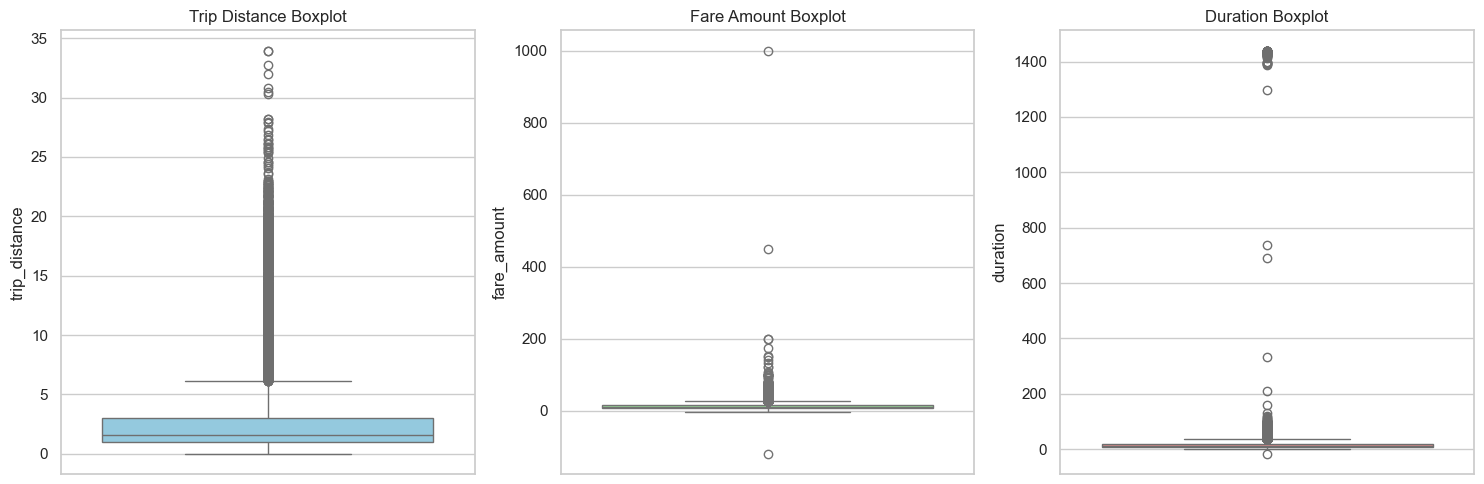

In [89]:

# we have created a table including 1 row and 2 column
fig , axes = plt.subplots(nrows = 1 , ncols = 3 , figsize = (15,5))

sns.boxplot(data = df0['trip_distance'], ax= axes[0]  , color = 'skyblue')
axes[0].set_title('Trip Distance Boxplot')

sns.boxplot(data= df0['fare_amount'], ax= axes[1] , color = 'lightgreen')
axes[1].set_title('Fare Amount Boxplot')

sns.boxplot(data = df0['duration'] , ax = axes[2] , color = 'lightcoral')
axes[2].set_title('Duration Boxplot')

# we can use tight_layout() to automatically adjust the spacing between subplots to prevent overlapping
plt.tight_layout() 
plt.show()



**Questions:** 
1. Which variable(s) contains outliers? 

2. Are the values in the `trip_distance` column unbelievable?

3. What about the lower end? Do distances, fares, and durations of 0 (or negative values) make sense?

==> ENTER YOUR RESPONSE HERE
1. All three variables contain outliers. Some are extreme, but others not so much.

2. It's 30 miles from the southern tip of Staten Island to the northern end of Manhattan and that's in a straight line. With this knowledge and the distribution of the values in this column, it's reasonable to leave these values alone and not alter them. However, the values for `fare_amount` and `duration` definitely seem to have problematic outliers on the higher end.

3. Probably not for the latter two, but for `trip_distance` it might be okay.

### Task 2e. Imputations

#### `trip_distance` outliers

You know from the summary statistics that there are trip distances of 0. Are these reflective of erroneous data, or are they very short trips that get rounded down?

To check, sort the column values, eliminate duplicates, and inspect the least 10 values. Are they rounded values or precise values?

In [90]:
# Are trip distances of 0 bad data or very short trips rounded down?

print(df0['trip_distance'].drop_duplicates().sort_values( ascending = True).head(10)) # you can use .nsmallest(10)) instead of .sort_values( ascending = True).head(10)

# Also we should check relationship between  'trip distance'   and  'fare amount' when trip distance = 0 this way ı can understand whether they rounded  
print("\nPRİCE OF TRİP DİSTANCE WHEN İS 0\n")      
print(df0[df0['trip_distance'] == 0]['fare_amount'].head(10))




128      0.00
2985     0.01
323      0.02
3158     0.03
1510     0.04
10146    0.05
4423     0.06
922      0.07
4623     0.08
22035    0.09
Name: trip_distance, dtype: float64

PRİCE OF TRİP DİSTANCE WHEN İS 0

128    20.0
246     2.5
291     2.5
319     2.5
424     2.5
470    34.0
472     9.5
572    52.0
647     2.5
795     8.0
Name: fare_amount, dtype: float64


The distances are captured with a high degree of precision. However, it might be possible for trips to have distances of zero if a passenger summoned a taxi and then changed their mind. Besides, are there enough zero values in the data to pose a problem?

Calculate the count of rides where the `trip_distance` is zero.

In [91]:
#Check how many trips have a distance of 0
sum(df0['trip_distance']==0)

148

#### `fare_amount` outliers

In [92]:
#Check distribution of fare_amount column
df0['fare_amount'].describe()

count    22699.000000
mean        13.026629
std         13.243791
min       -120.000000
25%          6.500000
50%          9.500000
75%         14.500000
max        999.990000
Name: fare_amount, dtype: float64

**Question:** What do you notice about the values in the `fare_amount` column?

It's have negative values that cannot be possible for that we should remove negative values

Impute values less than $0 with `0`.

In [93]:
# Impute values less than $0 with 0

df0['fare_amount'] = np.where(df0['fare_amount'] < 0, 0, df0['fare_amount'])

print(df0['fare_amount'].min())
print(df0['fare_amount'].nsmallest(10))

0.0
314      0.0
1646     0.0
4402     0.0
4423     0.0
5448     0.0
5722     0.0
5758     0.0
8204     0.0
10281    0.0
10506    0.0
Name: fare_amount, dtype: float64


Now impute the maximum value as `Q3 + (6 * IQR)`.

In [94]:

    #Impute upper-limit values in specified columns based on their interquartile range.

   # Arguments:
        #column_list: A list of columns to iterate over
       # iqr_factor: A number representing x in the formula:
                  #  Q3 + (x * IQR). Used to determine maximum threshold,
                  #  beyond which a point is considered an outlier.

   # The IQR is computed for each column in column_list and values exceeding
   # the upper threshold for each column are imputed with the upper threshold value.
    
def iqr(df, column_list , iqr_factor):

        
        for column in column_list:
        
    # Reassign minimum to zero
            df.loc[df[column] < 0 , column] = 0
        
    # Calculate upper threshold
            Q1 = df[column].quantile( 0.25)
            Q3 = df[column].quantile( 0.75)
            IQR = Q3 - Q1
            upper_threshold = Q3 + (iqr_factor * IQR)
            
        # Reassign values > threshold to threshold    
            df[column] = np.where(
            df[column] > upper_threshold,
            upper_threshold,
            df[column] )
                
            
        # df.loc[df0[column] > upper_threshold, column] = upper_threshold
            
            
column_list1 = ['fare_amount' , 'trip_distance' , 'duration']  

iqr(df0, column_list1 , 6)
    



#### `duration` outliers


In [95]:
# Call .describe() for duration outliers

for column in column_list1:
    print (f"{column} staticsal summary after IQR \n",df0[column].describe())

fare_amount staticsal summary after IQR 
 count    22699.000000
mean        12.897913
std         10.541137
min          0.000000
25%          6.500000
50%          9.500000
75%         14.500000
max         62.500000
Name: fare_amount, dtype: float64
trip_distance staticsal summary after IQR 
 count    22699.000000
mean         2.823424
std          3.252029
min          0.000000
25%          0.990000
50%          1.610000
75%          3.060000
max         15.480000
Name: trip_distance, dtype: float64
duration staticsal summary after IQR 
 count    22699.000000
mean        14.460555
std         11.947043
min          0.000000
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64


The `duration` column has problematic values at both the lower and upper extremities.

* **Low values:** There should be no values that represent negative time. Impute all negative durations with `0`.

* **High values:** Impute high values the same way you imputed the high-end outliers for fares: `Q3 + (6 * IQR)`.

### Task 3a. Feature engineering

#### Create `mean_distance` column

When deployed, the model will not know the duration of a trip until after the trip occurs, so you cannot train a model that uses this feature. However, you can use the statistics of trips you *do* know to generalize about ones you do not know.

In this step, create a column called `mean_distance` that captures the mean distance for each group of trips that share pickup and dropoff points.

For example, if your data were:

|Trip|Start|End|Distance|
|--: |:---:|:-:|    |
| 1  | A   | B | 1  |
| 2  | C   | D | 2  |
| 3  | A   | B |1.5 |
| 4  | D   | C | 3  |

The results should be:
```
A -> B: 1.25 miles
C -> D: 2 miles
D -> C: 3 miles
```

Notice that C -> D is not the same as D -> C. All trips that share a unique pair of start and end points get grouped and averaged.

Then, a new column `mean_distance` will be added where the value at each row is the average for all trips with those pickup and dropoff locations:

|Trip|Start|End|Distance|mean_distance|
|--: |:---:|:-:|  :--   |:--   |
| 1  | A   | B | 1      | 1.25 |
| 2  | C   | D | 2      | 2    |
| 3  | A   | B |1.5     | 1.25 |
| 4  | D   | C | 3      | 3    |


Begin by creating a helper column called `pickup_dropoff`, which contains the unique combination of pickup and dropoff location IDs for each row.

One way to do this is to convert the pickup and dropoff location IDs to strings and join them, separated by a space. The space is to ensure that, for example, a trip with pickup/dropoff points of 12 & 151 gets encoded differently than a trip with points 121 & 51.

So, the new column would look like this:

|Trip|Start|End|pickup_dropoff|
|--: |:---:|:-:|  :--         |
| 1  | A   | B | 'A B'        |
| 2  | C   | D | 'C D'        |
| 3  | A   | B | 'A B'        |
| 4  | D   | C | 'D C'        |


In [96]:
# Create `pickup_dropoff` column

df0['pickup_dropoff'] = df0['PULocationID'].astype(str) + ' ' + df0['DOLocationID'].astype(str)
df0['pickup_dropoff'].head(2)

0    100 231
1     186 43
Name: pickup_dropoff, dtype: object

Now, use a `groupby()` statement to group each row by the new `pickup_dropoff` column, compute the mean, and capture the values only in the `trip_distance` column. Assign the results to a variable named `grouped`.

In [97]:

avg_trip_distance =  df0.groupby('pickup_dropoff').mean(numeric_only=True)[['trip_distance']]

avg_trip_distance = avg_trip_distance.sort_values(by='trip_distance', ascending=True)

print(avg_trip_distance.head(30))

                trip_distance
pickup_dropoff               
264 113                  0.00
264 143                  0.00
168 168                  0.00
264 100                  0.00
75 264                   0.00
132 264                  0.00
143 264                  0.00
175 175                  0.00
55 55                    0.00
61 61                    0.00
113 264                  0.00
170 264                  0.00
233 264                  0.00
246 264                  0.00
164 264                  0.00
234 264                  0.00
244 244                  0.00
193 7                    0.00
163 264                  0.00
264 193                  0.00
238 264                  0.00
264 236                  0.00
43 264                   0.00
208 208                  0.00
82 82                    0.00
41 264                   0.00
162 264                  0.00
186 264                  0.00
145 264                  0.00
197 197                  0.01


`grouped` is an object of the `DataFrame` class.

1. Convert it to a dictionary using the [`to_dict()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_dict.html) method. Assign the results to a variable called `grouped_dict`. This will result in a dictionary with a key of `trip_distance` whose values are another dictionary. The inner dictionary's keys are pickup/dropoff points and its values are mean distances. This is the information you want.

```
Example:
grouped_dict = {'trip_distance': {'A B': 1.25, 'C D': 2, 'D C': 3}
```

2. Reassign the `grouped_dict` dictionary so it contains only the inner dictionary. In other words, get rid of `trip_distance` as a key, so:

```
Example:
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
 ```

In [131]:
# 1. Convert `grouped` to a dictionary
#For memory optimization  we convert to dict and then we reassign to only contain the inner dictionary

grouped_dict = avg_trip_distance.to_dict()

print("Grouped dictionary with inner dictionary: ")
# for print five elements of the dictionary with inner dictionary
dis_anahtar = list(grouped_dict.keys())[0] 
ilk_5_ic_veri = dict(list(grouped_dict[dis_anahtar].items())[:5])
print({dis_anahtar: ilk_5_ic_veri}, "\n")

# 2. Reassign to only contain the inner dictionary
grouped_dict = grouped_dict['trip_distance']

print("Grouped dictionary without inner dictionary: ")
# for print five elements of the dictionary
print(list(grouped_dict.items())[:5], "\n")




Grouped dictionary with inner dictionary: 
{'trip_distance': {'264 113': 0.0, '264 143': 0.0, '168 168': 0.0, '264 100': 0.0, '75 264': 0.0}} 

Grouped dictionary without inner dictionary: 
[('264 113', 0.0), ('264 143', 0.0), ('168 168', 0.0), ('264 100', 0.0), ('75 264', 0.0)] 



1. Create a `mean_distance` column that is a copy of the `pickup_dropoff` helper column.

2. Use the [`map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html#pandas-series-map) method on the `mean_distance` series. Pass `grouped_dict` as its argument. Reassign the result back to the `mean_distance` series.
</br></br>
When you pass a dictionary to the `Series.map()` method, it will replace the data in the series where that data matches the dictionary's keys. The values that get imputed are the values of the dictionary.

```
Example:
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 'A B'        |
| 'C D'        |
| 'A B'        |
| 'D C'        |
| 'E F'        |

```
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
df['mean_distance`] = df['mean_distance'].map(grouped_dict)
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 1.25         |
| 2            |
| 1.25         |
| 3            |
| NaN          |

When used this way, the `map()` `Series` method is very similar to `replace()`, however, note that `map()` will impute `NaN` for any values in the series that do not have a corresponding key in the mapping dictionary, so be careful.

In [99]:
# 1. Create a mean_distance column that is a copy of the pickup_dropoff helper column
df0['mean_distance'] = df0['pickup_dropoff']

# 2. Map `grouped_dict` to the `mean_distance` column
df0['mean_distance'] = df0['mean_distance'].map(grouped_dict)

# Confirm that it worked
df0[(df0['PULocationID']==100) & (df0['DOLocationID']==231)][['mean_distance']] 

,mean_distance
0,3.521667
4909,3.521667
16636,3.521667
18134,3.521667
19761,3.521667
20581,3.521667


#### Create `mean_duration` column

Repeat the process used to create the `mean_distance` column to create a `mean_duration` column.

In [100]:

# Create a dictionary where keys are unique pickup_dropoffs and values are
# mean trip duration for all trips with those pickup_dropoff combos

df0['mean_duration'] = df0['pickup_dropoff'].map(df0.groupby('pickup_dropoff')['duration'].mean())

# Confirm that it worked
df0[(df0['PULocationID']==100) & (df0['DOLocationID']==231)][['mean_duration']]

,mean_duration
0,22.847222
4909,22.847222
16636,22.847222
18134,22.847222
19761,22.847222
20581,22.847222


#### Create `day` and `month` columns

Create two new columns, `day` (name of day) and `month` (name of month) by extracting the relevant information from the `tpep_pickup_datetime` column.

In [101]:

#Before extracting day you should convert the column to datetime format if it is not already in that format.
print(df0['tpep_pickup_datetime'].head(5), "\n")

print("Type of tpep_pickup_datetime column: ", df0['tpep_pickup_datetime'].dtype , "\n")

# Create 'day' col
#day_name() returns the day of the week as a string, e.g. 'Monday', 'Tuesday', etc.
df0['day'] = df0['tpep_pickup_datetime'].dt.day_name().str.lower()

print(df0['day'].head(5))

# Create 'month' col                                                     
# strftime('%b') returns the month as a string, e.g. 'Jan', 'Feb', etc.
# strftime(%m %d %Y)
df0['month'] = df0['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

print(df0['month'].head(5))


0   2017-03-25 08:55:43
1   2017-04-11 14:53:28
2   2017-12-15 07:26:56
3   2017-05-07 13:17:59
4   2017-04-15 23:32:20
Name: tpep_pickup_datetime, dtype: datetime64[ns] 

Type of tpep_pickup_datetime column:  datetime64[ns] 

0    saturday
1     tuesday
2      friday
3      sunday
4    saturday
Name: day, dtype: object
0    mar
1    apr
2    dec
3    may
4    apr
Name: month, dtype: object


#### Create `rush_hour` column

Define rush hour as:
* Any weekday (not Saturday or Sunday) AND
* Either from 06:00&ndash;10:00 or from 16:00&ndash;20:00

Create a binary `rush_hour` column that contains a 1 if the ride was during rush hour and a 0 if it was not.

In [102]:
# Create 'rush_hour' col

df0['rush_hour'] = df0['tpep_pickup_datetime'].dt.hour
print("type of rush_hour column:", df0['rush_hour'].dtype) # type of rush_hour column: int32 so we can use between() method to check if the hour is between 6 and 17 (inclusive) for rush hour.


# If day is Saturday or Sunday, impute 0 in `rush_hour` column
# you should use & and | operators instead of and , or operators. Also you should use parentheses to group the conditions properly.
df0['rush_hour'] = np.where((~df0['tpep_pickup_datetime'].isin(['saturday' , 'sunday']))  &  (df0['rush_hour'].between(6,10))  | df0['rush_hour'].between(16,20)
                              , 1 , 0 )




type of rush_hour column: int32


In [103]:
#Check the distribution of the `rush_hour` column
print(df0['rush_hour'].head(10))

0    1
1    0
2    1
3    0
4    0
5    1
6    1
7    1
8    1
9    0
Name: rush_hour, dtype: int32


### Task 4. Scatter plot

Create a scatterplot to visualize the relationship between `mean_duration` and `fare_amount`.

C:\Users\faruk\AppData\Local\Temp\ipykernel_444\4174696337.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = df0 , x =df0['mean_duration'] , y = df0['fare_amount'] , palette = 'viridis')


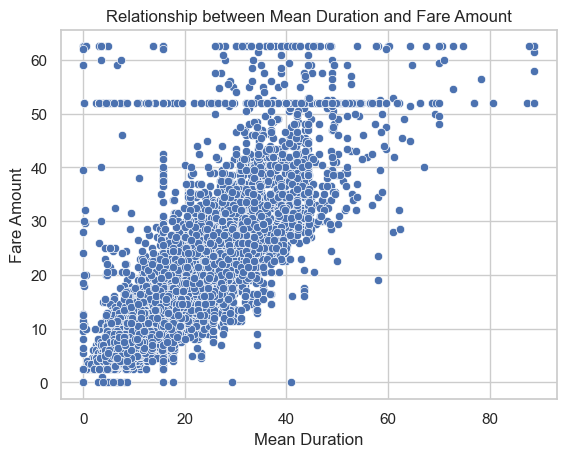

In [104]:
# Create a scatterplot to visualize the relationship between variables of interest

plt.figure()
sns.scatterplot(data = df0 , x =df0['mean_duration'] , y = df0['fare_amount'] , palette = 'viridis')
plt.xlabel('Mean Duration')
plt.ylabel('Fare Amount')
plt.title('Relationship between Mean Duration and Fare Amount')

plt.show()

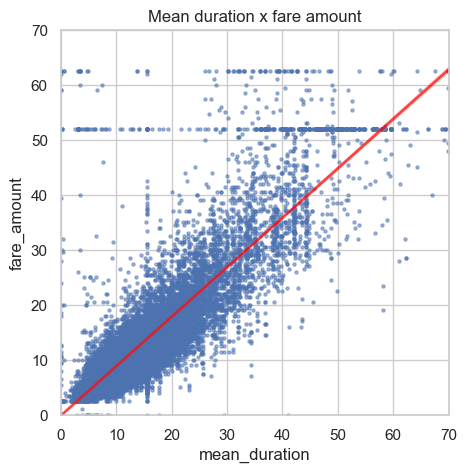

In [105]:
#.set the style of the plot to 'whitegrid' for better aesthetics.
sns.set(style='whitegrid')
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(5)
sns.regplot(x=df0['mean_duration'], y=df0['fare_amount'],
            scatter_kws={'alpha':0.5, 's':5},
            line_kws={'color':'red', 'alpha':0.7, 'lw':2})
plt.ylim(0, 70)
plt.xlim(0, 70)
plt.title('Mean duration x fare amount')
plt.show()

The `mean_duration` variable correlates with the target variable. But what are the horizontal lines around fare amounts of 52 dollars and 63 dollars? What are the values and how many are there?

You know what one of the lines represents. 62 dollars and 50 cents is the maximum that was imputed for outliers, so all former outliers will now have fare amounts of \$62.50. What is the other line?

Check the value of the rides in the second horizontal line in the scatter plot.

In [106]:
### YOUR CODE HERE ###
df0[df0['fare_amount'] > 50]['fare_amount'].value_counts().head(20)

fare_amount
52.0    514
62.5     84
59.0      9
50.5      9
57.5      8
51.0      7
60.0      6
55.0      6
51.5      6
53.0      4
52.5      4
61.0      3
62.0      3
55.5      3
56.0      3
56.5      3
58.5      2
59.5      2
61.5      2
57.0      2
Name: count, dtype: int64

Examine the first 30 of these trips.

In [107]:
# Set pandas to display all columns

pd.set_option('display.max_columns', None)
df0[df0['fare_amount']==52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,15.48,2,N,236,132,1,52.0,0.0,0.5,14.58,5.54,0.3,72.92,36.800000,236 132,15.480000,40.500000,sunday,mar,1
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,15.48,2,N,132,163,1,52.0,0.0,0.5,0.00,0.00,0.3,52.80,66.850000,132 163,15.480000,52.941667,saturday,jun,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,0.966667,132 132,1.941034,3.021839,saturday,nov,1
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,15.48,2,N,132,79,2,52.0,0.0,0.5,0.00,0.00,0.3,52.80,29.183333,132 79,15.480000,47.275000,wednesday,dec,0
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,15.48,2,N,132,234,1,52.0,0.0,0.5,14.64,5.76,0.3,73.20,29.483333,132 234,15.480000,49.833333,sunday,sep,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,15.48,2,N,132,48,2,52.0,4.5,0.5,0.00,5.54,0.3,62.84,39.833333,132 48,15.480000,58.246032,tuesday,feb,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,15.616667,228 88,4.730000,15.616667,monday,jun,0
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,15.48,2,N,132,48,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,45.450000,132 48,15.480000,58.246032,thursday,aug,0
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,15.48,2,N,186,132,2,52.0,0.0,0.5,0.00,5.76,0.3,58.56,42.850000,186 132,15.480000,42.920000,tuesday,sep,0
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,15.48,2,N,132,148,1,52.0,0.0,0.5,5.00,0.00,0.3,57.80,71.583333,132 148,15.480000,46.340476,sunday,apr,0


**Question:** What do you notice about the first 30 trips?

It seems that almost all of the trips in the first 30 rows where the fare amount was \$52 either begin or end at location 132, and all of them have a `RatecodeID` of 2.

There is no readily apparent reason why PULocation 132 should have so many fares of 52 dollars. They seem to occur on all different days, at different times, with both vendors, in all months. However, there are many toll amounts of $5.76 and \\$5.54. This would seem to indicate that location 132 is in an area that frequently requires tolls to get to and from. It's likely this is an airport.


The data dictionary says that `RatecodeID` of 2 indicates trips for JFK, which is John F. Kennedy International Airport. A quick Google search for "new york city taxi flat rate \$52" indicates that in 2017 (the year that this data was collected) there was indeed a flat fare for taxi trips between JFK airport (in Queens) and Manhattan.

Because `RatecodeID` is known from the data dictionary, the values for this rate code can be imputed back into the data after the model makes its predictions. This way you know that those data points will always be correct

### Task 5. Isolate modeling variables

Drop features that are redundant, irrelevant, or that will not be available in a deployed environment.

In [108]:
### YOUR CODE HERE ###

df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

In [109]:

df1 = df0.copy()

df1 = df1.drop(['Unnamed: 0', 'tpep_dropoff_datetime', 'tpep_pickup_datetime',
               'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
               'payment_type', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
               'total_amount', 'tpep_dropoff_datetime', 'tpep_pickup_datetime', 'duration',
               'pickup_dropoff', 'day', 'month'
               ], axis=1) #axis=1 means we are dropping columns, not rows

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int32  
dtypes: float64(3), int32(1), int64(2)
memory usage: 975.5 KB


### Task 6. Pair plot

Create a pairplot to visualize pairwise relationships between `fare_amount`, `mean_duration`, and `mean_distance`.

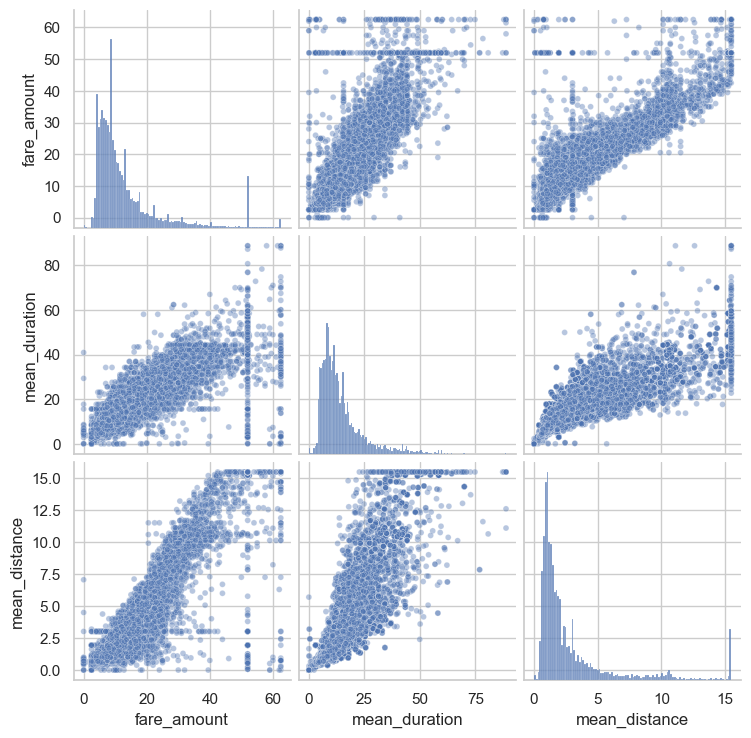

In [110]:
# Create a pairplot to visualize pairwise relationships between variables in the data
sns.pairplot(df1[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha':0.4, 'size':5},
             );



These variables all show linear correlation with each other. Investigate this further.

### Task 7. Identify correlations

Next, code a correlation matrix to help determine most correlated variables.

In [111]:
# Correlation matrix to help determine most correlated variables
matrix = df1.corr(method='pearson')
print(matrix)

                 VendorID  passenger_count  fare_amount  mean_distance  \
VendorID         1.000000         0.266463     0.001045       0.002933   
passenger_count  0.266463         1.000000     0.014942       0.014362   
fare_amount      0.001045         0.014942     1.000000       0.913404   
mean_distance    0.002933         0.014362     0.913404       1.000000   
mean_duration    0.001876         0.015852     0.859105       0.885492   
rush_hour       -0.001731        -0.012141    -0.024752      -0.041183   

                 mean_duration  rush_hour  
VendorID              0.001876  -0.001731  
passenger_count       0.015852  -0.012141  
fare_amount           0.859105  -0.024752  
mean_distance         0.885492  -0.041183  
mean_duration         1.000000  -0.025611  
rush_hour            -0.025611   1.000000  


Visualize a correlation heatmap of the data.

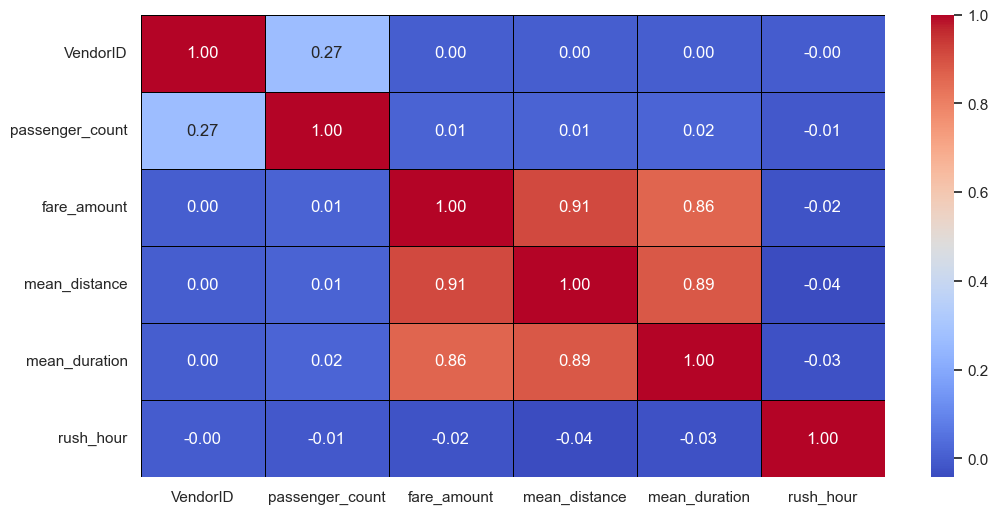

In [112]:
# Create correlation heatmap

plt.figure(figsize=(12, 6))
# annot makes the heatmap more informative by displaying the correlation coefficients on the heatmap itself. 
# you can assign a series to annot to display specific values on the heatmap, or you can set annot=True to display the correlation coefficients directly on the heatmap.
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.show()

**Question:** Which variable(s) are correlated with the target variable of `fare_amount`? 

mean_duration and mean_distance are both highly correlated with the target variable of fare_amount They're also both correlated with each other, with a Pearson correlation of 0.87.

Recall that highly correlated predictor variables can be bad for linear regression models when you want to be able to draw statistical inferences about the data from the model. However, correlated predictor variables can still be used to create an accurate predictor if the prediction itself is more important than using the model as a tool to learn about your data.

This model will predict fare_amount, which will be used as a predictor variable in machine learning models. Therefore, try modeling with both variables even though they are correlated.

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.


### Task 8a. Split data into outcome variable and features

In [113]:


df1.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         22699 non-null  int64  
 1   passenger_count  22699 non-null  int64  
 2   fare_amount      22699 non-null  float64
 3   mean_distance    22699 non-null  float64
 4   mean_duration    22699 non-null  float64
 5   rush_hour        22699 non-null  int32  
dtypes: float64(3), int32(1), int64(2)
memory usage: 975.5 KB


Set your X and y variables. X represents the features and y represents the outcome (target) variable.

In [114]:
# Remove the target column from the features


X = df1.drop(columns='fare_amount')

# Set y variable

y = df1['fare_amount']

# Display first few rows

print(X.head())


   VendorID  passenger_count  mean_distance  mean_duration  rush_hour
0         2                6       3.521667      22.847222          1
1         1                1       3.108889      24.470370          0
2         1                1       0.881429       7.250000          1
3         2                1       3.700000      30.250000          0
4         2                1       4.435000      14.616667          0


### Task 8b. Pre-process data


Dummy encode categorical variables

In [115]:
# Convert VendorID to string
X['VendorID'] = X['VendorID'].astype(str)

# Get dummies
VendorID_dummies = pd.get_dummies(X['VendorID'], drop_first = True)

### Split data into training and test sets

Create training and testing sets. The test set should contain 20% of the total samples. Set `random_state=0`.

In [116]:
# Create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Standardize the data

Use `StandardScaler()`, `fit()`, and `transform()` to standardize the `X_train` variables. Assign the results to a variable called `X_train_scaled`.

In [117]:
# Standardize the X variables
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
print('X_train scaled:', X_train_scaled)

X_train scaled: [[ 0.89575785 -0.49880314 -0.01260334  0.01271026  1.01671549]
 [ 0.89575785 -0.49880314  0.54126973 -0.03750208  1.01671549]
 [ 0.89575785  0.28284738 -0.45175539  0.03412234 -0.98355933]
 ...
 [ 0.89575785  0.28284738 -0.54843653 -0.5059124   1.01671549]
 [ 0.89575785  0.28284738 -0.23043207  0.39237496 -0.98355933]
 [ 0.89575785 -0.49880314  2.07339186  0.76643958 -0.98355933]]


### Fit the model

Instantiate your model and fit it to the training data.

In [118]:
# Fit your model to the training data
lr=LinearRegression() # We create an instance of the LinearRegression class and assign it to the variable lr. This instance will be used to fit the linear regression model to the training data.
lr.fit(X_train_scaled, y_train)

LinearRegression()

### Task 8c. Evaluate model

### Train data

Evaluate your model performance by calculating the residual sum of squares and the explained variance score (R^2). Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error.

In [119]:
# Evaluate the model performance on the training data
r_sq = lr.score(X_train_scaled, y_train)
print('Coefficient of determination:', r_sq)
y_pred_train = lr.predict(X_train_scaled)
print('R^2:', metrics.r2_score(y_train, y_pred_train)) 
print('MAE:', metrics.mean_absolute_error(y_train, y_pred_train))
print('MSE:', metrics.mean_squared_error(y_train, y_pred_train))
print('RMSE:',np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))

Coefficient of determination: 0.8496880120513164
R^2: 0.8496880120513164
MAE: 2.186782135608348
MSE: 16.98814838675005
RMSE: 4.121668155825994


### Test data

Calculate the same metrics on the test data. Remember to scale the `X_test` data using the scaler that was fit to the training data. Do not refit the scaler to the testing data, just transform it. Call the results `X_test_scaled`.

In [121]:
# Scale the X_test data
''' Remember that we use .transform() instead of .fit_transform() because we want to use the same scaling parameters (mean and standard deviation)
 that were calculated from the training data. This ensures that the test data is scaled in the same way as the training data, which is important for making accurate predictions.'''
X_test_scaled = Scaler.transform(X_test) #Model doesn't see the test data

In [122]:
# Evaluate the model performance on the testing data
### YOUR CODE HERE ###
r_sq_test = lr.score(X_test_scaled, y_test)
print('Coefficient of determination:', r_sq_test)
y_pred_test = lr.predict(X_test_scaled)
print('R^2:', metrics.r2_score(y_test, y_pred_test))
print('MAE:', metrics.mean_absolute_error(y_test, y_pred_test))
print('MSE:', metrics.mean_squared_error(y_test, y_pred_test))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))


Coefficient of determination: 0.8303799829202885
R^2: 0.8303799829202885
MAE: 2.1513481555962404
MSE: 17.531977376015305
RMSE: 4.187120415752967


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### Task 9a. Results

Use the code cell below to get `actual`,`predicted`, and `residual` for the testing set, and store them as columns in a `results` dataframe.

In [123]:
# Create a `results` dataframe

results = pd.DataFrame(data={'actual': y_test,
                             'predicted': y_pred_test.ravel()})
results['residual'] = results['actual'] - results['predicted']
results.head()


,actual,predicted,residual
9199,12.5,9.336200,3.163800
4955,6.0,8.304104,-2.304104
16833,12.0,8.801648,3.198352
13244,20.5,21.550937,-1.050937
1063,14.0,16.131186,-2.131186


### Task 9b. Visualize model results

Create a scatterplot to visualize `actual` vs. `predicted`.

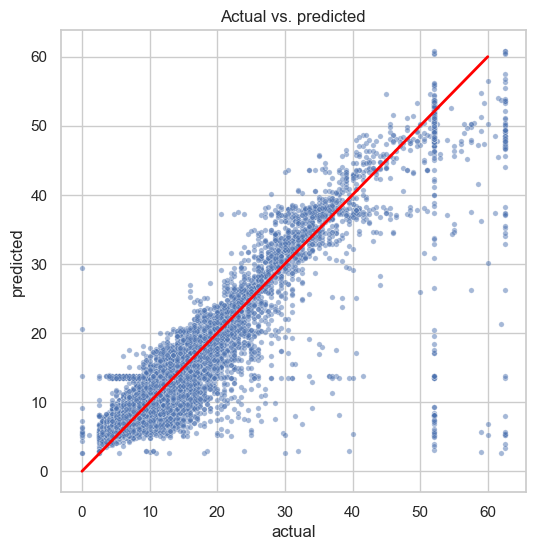

In [124]:
# Create a scatterplot to visualize `predicted` over `actual`
### YOUR CODE HERE ###
# Izgaralı beyaz temayı ayarlar
sns.set(style='whitegrid')

# 6x6 inç boyutunda bir grafik alanı oluşturur
plt.figure(figsize=(6, 6))

# Mavi noktalarla gerçek vs tahmin saçılım grafiğini çizer
# alpha: Noktaların saydamlığı, s: Nokta boyutu
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.5, s=15, color='b')

# Kırmızı mükemmel tahmin çizgisini (y = x) çizer
# [0, 60] değerleri grafikteki eksen limitlerine göre ayarlanmıştır
plt.plot([0, 60], [0, 60], color='red', linewidth=2)

# Başlık ve eksen isimlendirmeleri
plt.title('Actual vs. predicted')
plt.xlabel('actual')
plt.ylabel('predicted')

# Grafiği ekrana basar
plt.show()

Visualize the distribution of the `residuals` using a histogram.

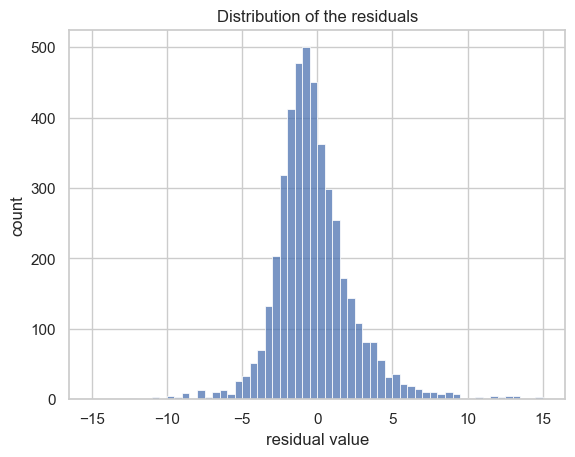

In [125]:
# Visualize the distribution of the `residuals`
### YOUR CODE HERE ###
# Visualize the distribution of the `residuals`
sns.histplot(results['residual'], bins=np.arange(-15,15.5,0.5))
plt.title('Distribution of the residuals')
plt.xlabel('residual value')
plt.ylabel('count');


In [126]:
# Calculate residual mean
### YOUR CODE HERE ###
results['residual'].mean()

0.02250882045623585

Create a scatterplot of `residuals` over `predicted`.

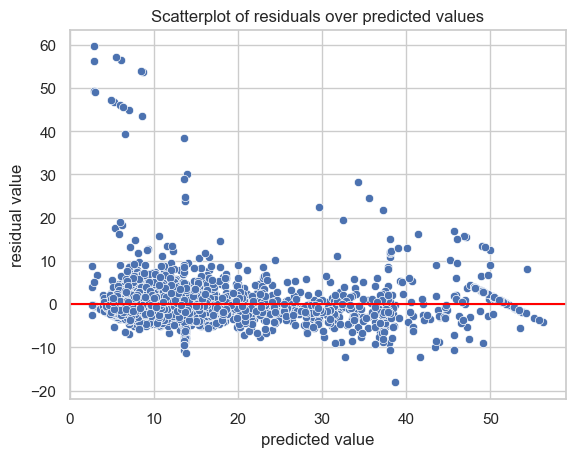

In [127]:
# Create a scatterplot of `residuals` over `predicted`
### YOUR CODE HERE ###
sns.scatterplot(x='predicted', y='residual', data=results)
plt.axhline(0, c='red')
plt.title('Scatterplot of residuals over predicted values')
plt.xlabel('predicted value')
plt.ylabel('residual value')
plt.show()

### Task 9c. Coefficients

Use the `coef_` attribute to get the model's coefficients. The coefficients are output in the order of the features that were used to train the model. Which feature had the greatest effect on trip fare?

In [128]:
# Output the model's coefficients
coefficients = pd.Series(lr.coef_, index=X.columns)
coefficients

VendorID          -0.013425
passenger_count    0.000806
mean_distance      7.553934
mean_duration      2.466199
rush_hour          0.107568
dtype: float64

What do these coefficients mean? How should they be interpreted?

==> ENTER YOUR RESPONSE HERE 

### Task 9d. Conclusion

1. What are the key takeaways from this notebook?



2. What results can be presented from this notebook?



==> ENTER YOUR RESPONSE HERE 

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 